In [1]:
import numpy as np
import numpy.linalg as lg
import matplotlib.pyplot as plt
%matplotlib inline
import jax.numpy as jnp
from tools import calculate_coefs_for_trunk

In [2]:
d = 64

In [3]:
l = 5
x = np.arange(d + 1).reshape(-1, 1)
cov = np.exp(- 0.5 * np.square((x - x.T)/l))
cov = 0.0625 * cov + np.ones_like(cov) * 100
noisy_cov = cov + np.eye(d + 1) * 0.01
transform_matrix = jnp.array((lg.solve(noisy_cov, cov[:, -1:])).T, jnp.float32)

In [4]:
log_discount = jnp.log(0.99 * 0.95)
weights = 0.99 / (1 - 0.99 * 0.95) * (1 - jnp.exp(log_discount * jnp.arange(d + 1)))
weights = weights * jnp.where(jnp.arange(d + 1) < d, 1 - 0.95, 1)
weights = weights - jnp.where(jnp.arange(d + 1) < d, 1.0, 0.0)

In [5]:
# weights = weights * jnp.where(jnp.arange(d + 1) < d, 1, 0) + transform_matrix.squeeze(0)[::-1] * weights[-1]
weights = weights * jnp.where(jnp.arange(d + 1) < d, 1, 0) + transform_matrix.squeeze(0) * weights[-1]

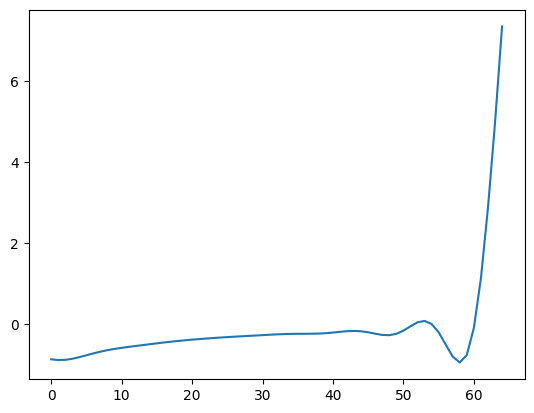

In [6]:
plt.plot(jnp.arange(d + 1), weights)
plt.show()

In [7]:
reward_weights = (1 - jnp.exp(log_discount * jnp.arange(d) + log_discount)) / (1 - 0.99 * 0.95)

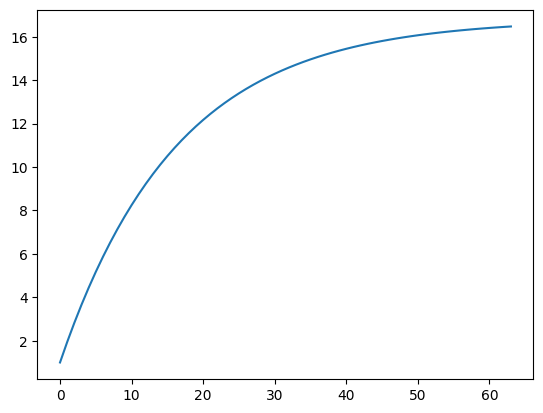

In [8]:
plt.plot(jnp.arange(d), reward_weights)
plt.show()

In [7]:
reward_coefs, v_coefs = calculate_coefs_for_trunk(d, 0, 64, 10, 0.99, 0.95)

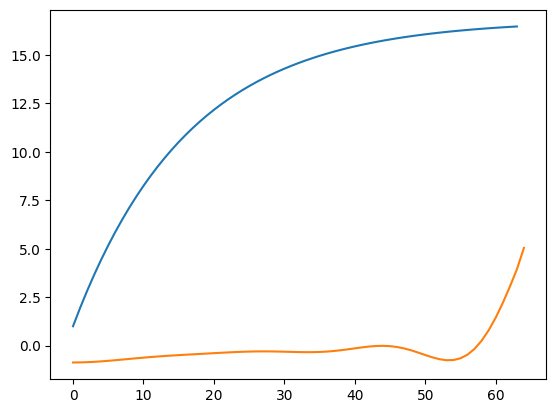

In [8]:
plt.plot(jnp.arange(d), reward_coefs.squeeze(-1))
plt.plot(jnp.arange(d + 1), v_coefs.squeeze(-1))
plt.show()